In [6]:
# Para Windows con GPU NVIDIA:
# 1. Instalar CUDA Toolkit 11.2: https://developer.nvidia.com/cuda-11.2.0-download-archive
# 2. Instalar cuDNN 8.1: https://developer.nvidia.com/cudnn
# 3. Luego ejecutar:
%pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\rodri\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~umpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import traceback
tfd = tfp.distributions
tfpl = tfp.layers
tfb = tfp.bijectors
print("TF version:", tf.__version__)
print("TFP version:", tfp.__version__)

TF version: 2.10.0
TFP version: 0.18.0


In [8]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Reshape, Conv2D, MaxPooling2D, UpSampling2D, Input, LayerNormalization, Concatenate, Conv2DTranspose, BatchNormalization
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



In [10]:
dataset_path = 'C:\\Users\\rodri\\Downloads\\images' #Cambiar esta ruta dónde se descargue el dataset 

datagen = ImageDataGenerator(
    rescale=1./255,  
    validation_split=0.3
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  
    batch_size=32,
    class_mode='input',
    subset='training'
)
test_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='input',
    subset='validation'
)

Found 252 images belonging to 9 classes.
Found 107 images belonging to 9 classes.
Found 107 images belonging to 9 classes.


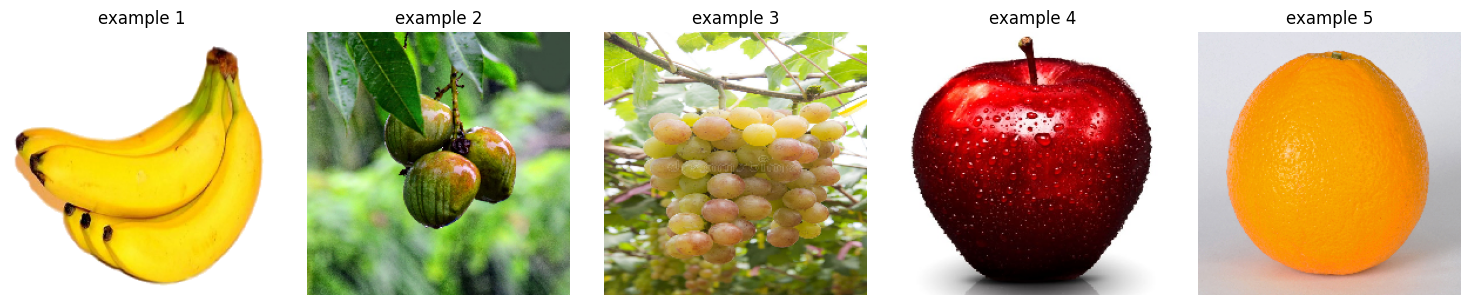

In [11]:
images, labels = next(train_generator)   

class_names = list(train_generator.class_indices.keys()) 

n_examples = 5  
fig, axs = plt.subplots(1, n_examples, figsize=(n_examples*3, 3))
for j in range(n_examples):
    
    img = images[j]
    axs[j].imshow(img) 
    axs[j].set_title(f"example {j+1}")
    axs[j].axis('off')
plt.tight_layout()
plt.show()

In [12]:
"""encoded_dim = 256

encoder = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Dropout(0.1),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    layers.Dropout(0.2),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'), 
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(encoded_dim, activation='relu'),
    layers.Dropout(0.2)
])
"""

"encoded_dim = 256\n\nencoder = Sequential([\n    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2), padding='same'),\n    layers.Dropout(0.1),\n\n    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2), padding='same'),\n    layers.Dropout(0.1),\n\n    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2), padding='same'),\n    layers.Dropout(0.2),\n    \n    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.MaxPooling2D((2, 2), padding='same'), \n    layers.Dropout(0.2),\n\n    layers.GlobalAveragePooling2D(),\n    layers.Dense(encoded_dim, activation='relu'),\n    layers.Dropout(0.2)\n])\n"

In [13]:
"""
decoder = Sequential([
    layers.Dense(14*14*256, activation='relu', input_shape=(encoded_dim,)),
    layers.Reshape((14, 14, 256)),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.UpSampling2D((2, 2)),  
    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.UpSampling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.UpSampling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.UpSampling2D((2, 2)),
    layers.Dropout(0.1),

    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])
"""

"\ndecoder = Sequential([\n    layers.Dense(14*14*256, activation='relu', input_shape=(encoded_dim,)),\n    layers.Reshape((14, 14, 256)),\n    \n    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.UpSampling2D((2, 2)),  \n    layers.Dropout(0.2),\n\n    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.UpSampling2D((2, 2)),\n    layers.Dropout(0.2),\n\n    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.UpSampling2D((2, 2)),\n    layers.Dropout(0.1),\n\n    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),\n    layers.BatchNormalization(),\n    layers.UpSampling2D((2, 2)),\n    layers.Dropout(0.1),\n\n    layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')\n])\n"

In [14]:
"""input_img = tf.keras.Input(shape=(224, 224, 3))
encoded = encoder(input_img)
decoded = decoder(encoded)

autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.summary()

autoencoder.compile(optimizer=Adam(learning_rate=0.0001), 
                loss='mse',
                metrics=['mae'])
                """

"input_img = tf.keras.Input(shape=(224, 224, 3))\nencoded = encoder(input_img)\ndecoded = decoder(encoded)\n\nautoencoder = Model(inputs=input_img, outputs=decoded)\nautoencoder.summary()\n\nautoencoder.compile(optimizer=Adam(learning_rate=0.0001), \n                loss='mse',\n                metrics=['mae'])\n                "

In [15]:
"""try:
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, min_delta=0.0001)
    history = autoencoder.fit(
        train_generator,
        epochs=100,
        validation_data=test_generator,
        callbacks=[early_stopping]
    )
except Exception as e:
    print(f"An error occurred during training: {e}")
"""

'try:\n    early_stopping = EarlyStopping(monitor=\'val_loss\', patience=10, restore_best_weights=True, min_delta=0.0001)\n    history = autoencoder.fit(\n        train_generator,\n        epochs=100,\n        validation_data=test_generator,\n        callbacks=[early_stopping]\n    )\nexcept Exception as e:\n    print(f"An error occurred during training: {e}")\n'

In [16]:
"""
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(loss, label='Pérdida de entrenamiento')
plt.plot(val_loss, label='Pérdida de validación')
plt.title('Curvas de pérdida del autoencoder')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""

"\nloss = history.history['loss']\nval_loss = history.history['val_loss']\n\nplt.figure(figsize=(8, 5))\nplt.plot(loss, label='Pérdida de entrenamiento')\nplt.plot(val_loss, label='Pérdida de validación')\nplt.title('Curvas de pérdida del autoencoder')\nplt.xlabel('Épocas')\nplt.ylabel('Pérdida')\nplt.legend()\nplt.grid(True)\nplt.tight_layout()\nplt.show()\n"

In [17]:
"""test_images, _ = next(test_generator)
example_images = test_images[:5]  


reconstructed_images = autoencoder.predict(example_images)


fig, axs = plt.subplots(2, 5, figsize=(15, 6))

for j in range(5):
    
    orig = example_images[j]
    axs[0, j].imshow(orig)
    axs[0, j].set_title('Original')
    axs[0, j].axis('off')
    
    
    recon = reconstructed_images[j]
    axs[1, j].imshow(recon)
    axs[1, j].set_title('Reconstruida')
    axs[1, j].axis('off')

plt.tight_layout()
plt.show()


mse_per_image = np.mean((example_images - reconstructed_images) ** 2, axis=(1, 2, 3))
print(f"\nError de reconstrucción (MSE) por imagen:")
for i, mse in enumerate(mse_per_image):
    print(f"  Imagen {i+1}: {mse:.6f}")
print(f"\nMSE promedio: {np.mean(mse_per_image):.6f}")
"""

'test_images, _ = next(test_generator)\nexample_images = test_images[:5]  \n\n\nreconstructed_images = autoencoder.predict(example_images)\n\n\nfig, axs = plt.subplots(2, 5, figsize=(15, 6))\n\nfor j in range(5):\n    \n    orig = example_images[j]\n    axs[0, j].imshow(orig)\n    axs[0, j].set_title(\'Original\')\n    axs[0, j].axis(\'off\')\n    \n    \n    recon = reconstructed_images[j]\n    axs[1, j].imshow(recon)\n    axs[1, j].set_title(\'Reconstruida\')\n    axs[1, j].axis(\'off\')\n\nplt.tight_layout()\nplt.show()\n\n\nmse_per_image = np.mean((example_images - reconstructed_images) ** 2, axis=(1, 2, 3))\nprint(f"\nError de reconstrucción (MSE) por imagen:")\nfor i, mse in enumerate(mse_per_image):\n    print(f"  Imagen {i+1}: {mse:.6f}")\nprint(f"\nMSE promedio: {np.mean(mse_per_image):.6f}")\n'

Este modelo NO funcionó, capta colores pero no es muy optimo, ahora será un modelo U-net con skip connection

In [18]:

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    
    return 0.7 * mse + 0.3 * ssim_loss

In [19]:

def build_unet_encoder():
    inputs = Input(shape=(224, 224, 3))
    
    # Block 1: 224x224 -> 112x112
    x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x1 = BatchNormalization()(x1)
    x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x1)
    x1 = BatchNormalization()(x1)  # skip1: 224x224x32
    p1 = MaxPooling2D((2, 2))(x1)  # 112x112x32
    p1 = layers.Dropout(0.1)(p1)
    
    # Block 2: 112x112 -> 56x56
    x2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    x2 = BatchNormalization()(x2)
    x2 = Conv2D(64, (3, 3), activation='relu', padding='same')(x2)
    x2 = BatchNormalization()(x2)  # skip2: 112x112x64
    p2 = MaxPooling2D((2, 2))(x2)  # 56x56x64
    p2 = layers.Dropout(0.1)(p2)
    
    # Block 3: 56x56 -> 28x28
    x3 = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    x3 = BatchNormalization()(x3)
    x3 = Conv2D(128, (3, 3), activation='relu', padding='same')(x3)
    x3 = BatchNormalization()(x3)  # skip3: 56x56x128
    p3 = MaxPooling2D((2, 2))(x3)  # 28x28x128
    p3 = layers.Dropout(0.2)(p3)
    
    # Block 4: 28x28 -> 14x14
    x4 = Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    x4 = BatchNormalization()(x4)
    x4 = Conv2D(256, (3, 3), activation='relu', padding='same')(x4)
    x4 = BatchNormalization()(x4)  # skip4: 28x28x256
    p4 = MaxPooling2D((2, 2))(x4)  # 14x14x256
    p4 = layers.Dropout(0.2)(p4)
    
    # Bottleneck: 14x14x512
    bottleneck = Conv2D(512, (3, 3), activation='relu', padding='same')(p4)
    bottleneck = BatchNormalization()(bottleneck)
    bottleneck = Conv2D(512, (3, 3), activation='relu', padding='same')(bottleneck)
    bottleneck = BatchNormalization()(bottleneck)  # 14x14x512
    
    # Retornamos: bottleneck(14x14x512), x4(28x28x256), x3(56x56x128), x2(112x112x64), x1(224x224x32)
    return Model(inputs, [bottleneck, x4, x3, x2, x1], name='unet_encoder')

encoder_unet = build_unet_encoder()
encoder_unet.summary()

Model: "unet_encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)    

In [20]:

def build_unet_decoder():
    # Inputs: bottleneck + 4 skip connections (dimensiones del encoder)
    bottleneck_input = Input(shape=(14, 14, 512))   # bottleneck
    skip4 = Input(shape=(28, 28, 256))              # x4
    skip3 = Input(shape=(56, 56, 128))              # x3  
    skip2 = Input(shape=(112, 112, 64))             # x2
    skip1 = Input(shape=(224, 224, 32))             # x1
    
    # Up-block 1: 14x14 -> 28x28
    u1 = UpSampling2D((2, 2))(bottleneck_input)  # 28x28x512
    u1 = Concatenate()([u1, skip4])              # 28x28x(512+256)
    u1 = Conv2D(256, (3, 3), activation='relu', padding='same')(u1)
    u1 = BatchNormalization()(u1)
    u1 = Conv2D(256, (3, 3), activation='relu', padding='same')(u1)
    u1 = BatchNormalization()(u1)
    u1 = layers.Dropout(0.2)(u1)
    
    # Up-block 2: 28x28 -> 56x56
    u2 = UpSampling2D((2, 2))(u1)  # 56x56x256
    u2 = Concatenate()([u2, skip3])  # 56x56x(256+128)
    u2 = Conv2D(128, (3, 3), activation='relu', padding='same')(u2)
    u2 = BatchNormalization()(u2)
    u2 = Conv2D(128, (3, 3), activation='relu', padding='same')(u2)
    u2 = BatchNormalization()(u2)
    u2 = layers.Dropout(0.2)(u2)
    
    # Up-block 3: 56x56 -> 112x112
    u3 = UpSampling2D((2, 2))(u2)  # 112x112x128
    u3 = Concatenate()([u3, skip2])  # 112x112x(128+64)
    u3 = Conv2D(64, (3, 3), activation='relu', padding='same')(u3)
    u3 = BatchNormalization()(u3)
    u3 = Conv2D(64, (3, 3), activation='relu', padding='same')(u3)
    u3 = BatchNormalization()(u3)
    u3 = layers.Dropout(0.1)(u3)
    
    # Up-block 4: 112x112 -> 224x224
    u4 = UpSampling2D((2, 2))(u3)  # 224x224x64
    u4 = Concatenate()([u4, skip1])  # 224x224x(64+32)
    u4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    u4 = BatchNormalization()(u4)
    u4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    u4 = BatchNormalization()(u4)
    u4 = layers.Dropout(0.1)(u4)
    
    # Output: 224x224x3
    output = Conv2D(3, (1, 1), activation='sigmoid', padding='same')(u4)
    
    return Model([bottleneck_input, skip4, skip3, skip2, skip1], output, name='unet_decoder')

decoder_unet = build_unet_decoder()
decoder_unet.summary()

Model: "unet_decoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 14, 14, 512  0           []                               
                                )]                                                                
                                                                                                  
 up_sampling2d (UpSampling2D)   (None, 28, 28, 512)  0           ['input_2[0][0]']                
                                                                                                  
 input_3 (InputLayer)           [(None, 28, 28, 256  0           []                               
                                )]                                                                
                                                                                       

In [21]:
inputs = Input(shape=(224, 224, 3))
encoder_outputs = encoder_unet(inputs)

# Encoder retorna: [bottleneck, x4, x3, x2, x1]
bottleneck = encoder_outputs[0]  # (14, 14, 512)
x4 = encoder_outputs[1]          # (28, 28, 256)
x3 = encoder_outputs[2]          # (56, 56, 128)
x2 = encoder_outputs[3]          # (112, 112, 64)
x1 = encoder_outputs[4]          # (224, 224, 32)

# Decoder espera: [bottleneck_input, skip4, skip3, skip2, skip1]
decoded = decoder_unet([bottleneck, x4, x3, x2, x1])

autoencoder_unet = Model(inputs, decoded, name='autoencoder_unet')

autoencoder_unet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=combined_loss,
    metrics=['mae']
)

autoencoder_unet.summary()

total_params = autoencoder_unet.count_params()
print(f"\nParámetros totales: {total_params:,}")


Model: "autoencoder_unet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 unet_encoder (Functional)      [(None, 14, 14, 512  4720160     ['input_7[0][0]']                
                                ),                                                                
                                 (None, 28, 28, 256                                               
                                ),                                                                
                                 (None, 56, 56, 128                                

In [22]:

try:
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=15,  
        restore_best_weights=True,
        min_delta=0.0001,
        verbose=1
    )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    history_unet = autoencoder_unet.fit(
        train_generator,
        epochs=50,
        validation_data=test_generator,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    

    
except Exception as e:
    print(f"\n Error durante el entrenamiento: {e}")
    traceback.print_exc()

Epoch 1/50
8/8 [==============================] - 186s 23s/step - loss: 0.3627 - mae: 0.2638 - val_loss: 0.2659 - val_mae: 0.3293 - lr: 1.0000e-04
Epoch 2/50
Epoch 2/50
8/8 [==============================] - 187s 24s/step - loss: 0.2909 - mae: 0.1823 - val_loss: 0.2589 - val_mae: 0.3232 - lr: 1.0000e-04
Epoch 3/50
Epoch 3/50
8/8 [==============================] - 180s 23s/step - loss: 0.2544 - mae: 0.1614 - val_loss: 0.2520 - val_mae: 0.3168 - lr: 1.0000e-04
Epoch 4/50
Epoch 4/50
8/8 [==============================] - 183s 23s/step - loss: 0.2302 - mae: 0.1488 - val_loss: 0.2475 - val_mae: 0.3125 - lr: 1.0000e-04
Epoch 5/50
Epoch 5/50
8/8 [==============================] - 182s 23s/step - loss: 0.2100 - mae: 0.1373 - val_loss: 0.2433 - val_mae: 0.3087 - lr: 1.0000e-04
Epoch 6/50
Epoch 6/50
8/8 [==============================] - 179s 22s/step - loss: 0.1958 - mae: 0.1332 - val_loss: 0.2395 - val_mae: 0.3054 - lr: 1.0000e-04
Epoch 7/50
8/8 [==============================] - 179s 22s/step

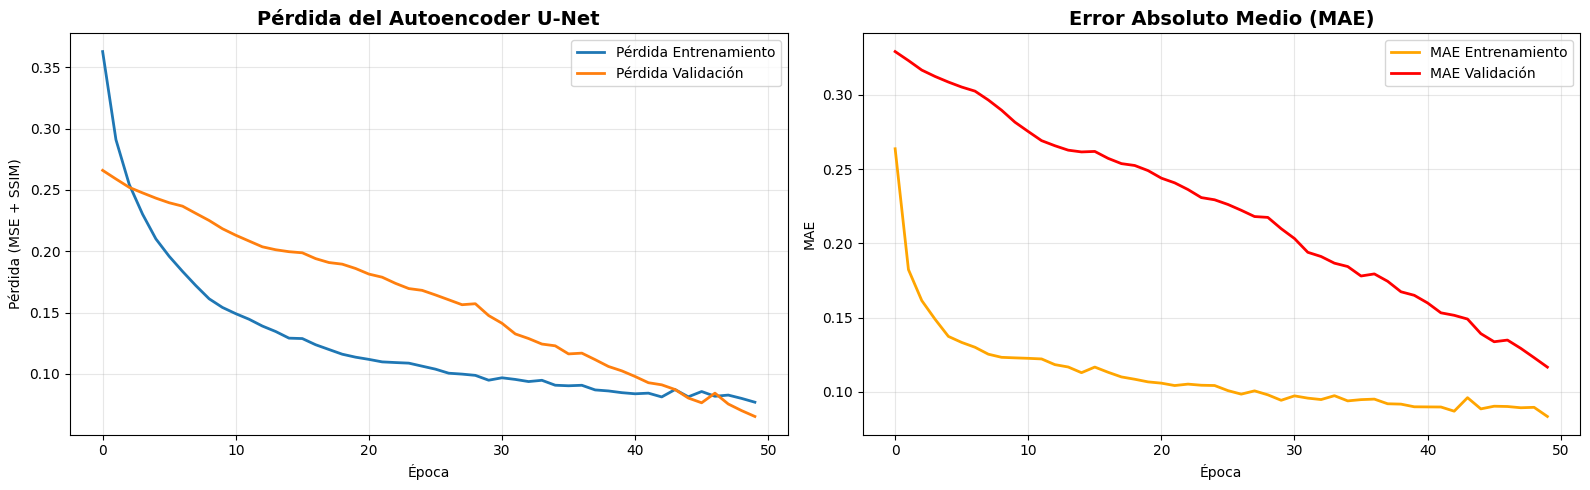

Pérdida final (entrenamiento): 0.076901
Pérdida final (validación):    0.065266
MAE final (entrenamiento):     0.083296
MAE final (validación):        0.116557


In [23]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_unet.history['loss'], label='Pérdida Entrenamiento', linewidth=2)
axes[0].plot(history_unet.history['val_loss'], label='Pérdida Validación', linewidth=2)
axes[0].set_title('Pérdida del Autoencoder U-Net', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (MSE + SSIM)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_unet.history['mae'], label='MAE Entrenamiento', linewidth=2, color='orange')
axes[1].plot(history_unet.history['val_mae'], label='MAE Validación', linewidth=2, color='red')
axes[1].set_title('Error Absoluto Medio (MAE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_train_loss = history_unet.history['loss'][-1]
final_val_loss = history_unet.history['val_loss'][-1]
final_train_mae = history_unet.history['mae'][-1]
final_val_mae = history_unet.history['val_mae'][-1]

print(f"Pérdida final (entrenamiento): {final_train_loss:.6f}")
print(f"Pérdida final (validación):    {final_val_loss:.6f}")
print(f"MAE final (entrenamiento):     {final_train_mae:.6f}")
print(f"MAE final (validación):        {final_val_mae:.6f}")


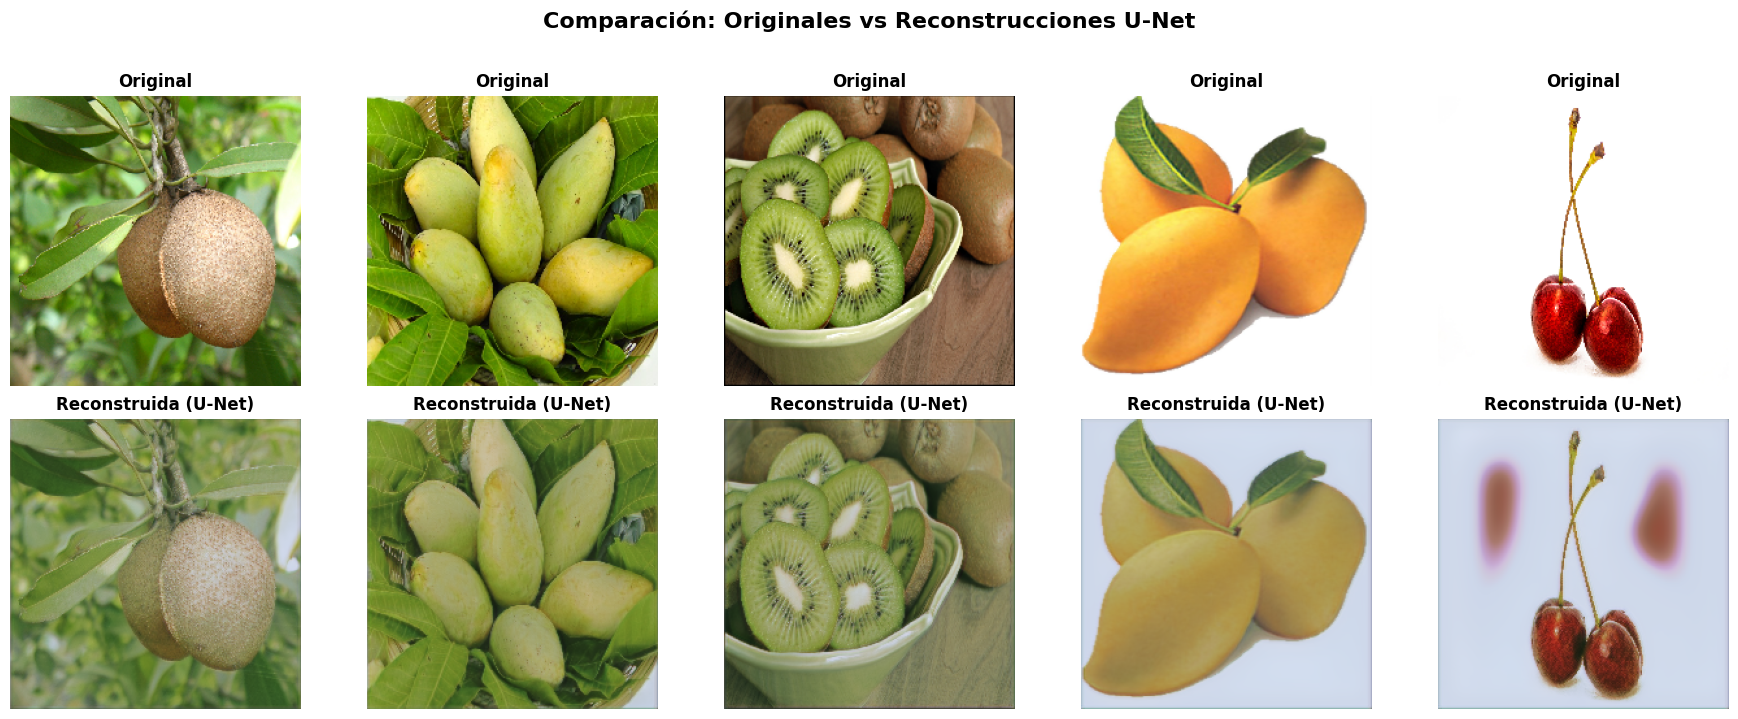

In [ ]:

test_images, _ = next(test_generator)
example_images = test_images[:5]


reconstructed_images_unet = autoencoder_unet.predict(example_images, verbose=0)


fig, axs = plt.subplots(2, 5, figsize=(18, 7))

for j in range(5):
    # Imagen original
    orig = example_images[j]
    axs[0, j].imshow(orig)
    axs[0, j].set_title('Original', fontsize=12, fontweight='bold')
    axs[0, j].axis('off')
    
    # Imagen reconstruida
    recon = np.clip(reconstructed_images_unet[j], 0, 1)
    axs[1, j].imshow(recon)
    axs[1, j].set_title('Reconstruida (U-Net)', fontsize=12, fontweight='bold')
    axs[1, j].axis('off')

plt.suptitle('Comparación: Originales vs Reconstrucciones U-Net', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_per_image = np.mean((example_images - reconstructed_images_unet) ** 2, axis=(1, 2, 3))
mae_per_image = np.mean(np.abs(example_images - reconstructed_images_unet), axis=(1, 2, 3))

ssim_scores = []
for i in range(len(example_images)):
    ssim_val = tf.image.ssim(
        tf.expand_dims(example_images[i], 0),
        tf.expand_dims(reconstructed_images_unet[i], 0),
        max_val=1.0
    ).numpy()[0]
    ssim_scores.append(ssim_val)



In [25]:
# Métricas del modelo U-Net

print("MÉTRICAS DE RECONSTRUCCIÓN U-NET")


for i in range(len(example_images)):
    print(f"\nImagen {i+1}:")
    print(f"  MSE:  {mse_per_image[i]:.6f}")
    print(f"  MAE:  {mae_per_image[i]:.6f}")
    print(f"  SSIM: {ssim_scores[i]:.4f}")


print("PROMEDIOS:")
print(f"  MSE promedio:  {np.mean(mse_per_image):.6f}")
print(f"  MAE promedio:  {np.mean(mae_per_image):.6f}")
print(f"  SSIM promedio: {np.mean(ssim_scores):.4f}")
print("=" * 50)


MÉTRICAS DE RECONSTRUCCIÓN U-NET

Imagen 1:
  MSE:  0.007856
  MAE:  0.073130
  SSIM: 0.8277

Imagen 2:
  MSE:  0.011230
  MAE:  0.089194
  SSIM: 0.7589

Imagen 3:
  MSE:  0.008931
  MAE:  0.076469
  SSIM: 0.8520

Imagen 4:
  MSE:  0.023152
  MAE:  0.129486
  SSIM: 0.9078

Imagen 5:
  MSE:  0.039328
  MAE:  0.167046
  SSIM: 0.8647
PROMEDIOS:
  MSE promedio:  0.018099
  MAE promedio:  0.107065
  SSIM promedio: 0.8422


In [ ]:

autoencoder_unet.save('autoencoder_unet.h5')
encoder_unet.save('encoder_unet_.h5')
decoder_unet.save('decoder_unet_.h5')

autoencoder_unet.save_weights('autoencoder_unet_weights.h5')
encoder_unet.save_weights('encoder_unet_weights.h5')
decoder_unet.save_weights('decoder_unet_weights.h5')



✅ Modelos guardados exitosamente
   - Modelos completos: autoencoder_unet_best.h5, encoder_unet.h5, decoder_unet.h5
   - Solo pesos: autoencoder_unet_weights.h5, encoder_unet_weights.h5, decoder_unet_weights.h5
✅ Modelos guardados exitosamente
   - Modelos completos: autoencoder_unet_best.h5, encoder_unet.h5, decoder_unet.h5
   - Solo pesos: autoencoder_unet_weights.h5, encoder_unet_weights.h5, decoder_unet_weights.h5
